# OpenCoesione: Ambiente — il pattern nazionale sotto quota 1 regge a livello regionale?

Follow-up del notebook `opencoesione_pagamenti_tema_v1.ipynb`.

- **Obiettivo**: verificare se il macro-tema Ambiente (ratio 0.921 nazionale) resta sotto 1 in tutte le regioni o se il risultato dipende da combinazioni specifiche.
- **Dati**: mart `mart_regione_tema` dal filone `opencoesione-pagamenti-ue-2014-2020`.
- **Perimetro**: dettaglio regione x tema per Ambiente, 20 regioni.
- **Nota**: i casi con ratio > 1 richiedono verifica metodologica (rendicontazione, cicli di programmazione).

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

pd.options.display.float_format = '{:,.2f}'.format

def find_workspace_root(start: Path) -> Path:
    # Il notebook sta in analisi-civiche/notebooks/opencoesione/
    # Il workspace root e' 3 livelli sopra
    candidate = start.resolve()
    # Se siamo dentro analisi-civiche, sali fino al livello che contiene dataset-incubator
    for _ in range(10):  # safety limit
        if (candidate / 'dataset-incubator').exists():
            return candidate
        parent = candidate.parent
        if parent == candidate:
            break
        candidate = parent
    raise RuntimeError(f'Workspace root non trovato da {start}')

WORKSPACE_ROOT = find_workspace_root(Path.cwd())
mart_path = WORKSPACE_ROOT / 'dataset-incubator' / 'out' / 'data' / 'mart' / 'opencoesione_pagamenti_ue_2014_2020' / '2020' / 'mart_regione_tema.parquet'

if not mart_path.exists():
    raise FileNotFoundError(f'Mart non trovato: {mart_path.resolve()}')

con = duckdb.connect()


### 1. Ambiente nel dettaglio regionale

La query nazionale dava Ambiente a 0.921 — l'unico macro-tema sotto 1.
Ora guardiamo il dettaglio regionale.

In [2]:
df = con.execute(
    """
    SELECT
        regione,
        n_progetti,
        finanz_ue_tot,
        tot_pagamenti_tot,
        round(tot_pagamenti_tot / finanz_ue_tot, 3) AS ratio_spesa
    FROM read_parquet($path)
    WHERE tema = 'Ambiente'
    ORDER BY finanz_ue_tot DESC
    """,
    {'path': str(mart_path)},
).fetchdf()


In [3]:
df['label'] = df.apply(
    lambda r: '> 1' if r['ratio_spesa'] > 1 else '< 1', axis=1
)
df[['regione', 'n_progetti', 'finanz_ue_tot', 'tot_pagamenti_tot', 'ratio_spesa', 'label']]


,regione,n_progetti,finanz_ue_tot,tot_pagamenti_tot,ratio_spesa,label
0,PUGLIA,914,"1,110,350,032.30","1,103,130,189.81",0.99,< 1
1,CAMPANIA,398,"1,061,752,308.93","1,050,905,564.66",0.99,< 1
2,SICILIA,355,"610,703,999.73","405,445,355.84",0.66,< 1
3,CALABRIA,480,"397,277,542.62","279,930,410.34",0.70,< 1
4,SARDEGNA,121,"98,709,473.54","114,622,733.59",1.16,> 1
5,BASILICATA,117,"79,809,764.73","49,974,982.41",0.63,< 1
6,LIGURIA,51,"77,899,228.49","90,552,276.85",1.16,> 1
7,TOSCANA,89,"57,328,791.14","50,464,702.06",0.88,< 1
8,LAZIO,91,"49,840,433.02","33,073,362.84",0.66,< 1
9,VENETO,83,"34,490,066.59","65,718,184.57",1.91,> 1


### Prime letture

**Ambiente NON e' uniformemente sotto 1.** Il dato nazionale 0.921 nasconde una realta' molto piu' frammentata:

**Puglia (0.993) e Campania (0.990)**: quasi al pareggio, ma tecnicamente sotto 1. Sono le due regioni con piu' fondi Ambiente — pesano da sole il **58.3%** del finanziamento UE Ambiente totale.
- **Sicilia (0.664), Calabria (0.705), Lazio (0.664), Basilicata (0.626), Emilia-Romagna (0.516), Molise (0.388)**: nettamente sotto. Qui il ritardo e' strutturale.
- **Veneto (1.91), Trentino-Alto Adige (1.95), Marche (1.76), Umbria (1.40), Valle d'Aosta (1.58)**: sopra 1, a volte di molto. Segnale che il rapporto pagamenti/finanz UE non e' un indicatore di efficienza puro — puo' riflettere anche rendicontazioni diverse, co-finanziamenti, o effetti contabili tra cicli.

**Conclusione**: il pattern nazionale "Ambiente sotto quota 1" e' reale ma dipende da due sole grandi regioni del Sud. Non e' un fenomeno uniforme.

### 2. Grafico

Il grafico confronta il ratio per regione, ordinato per finanziamento UE decrescente. La linea rossa segna la soglia 1.

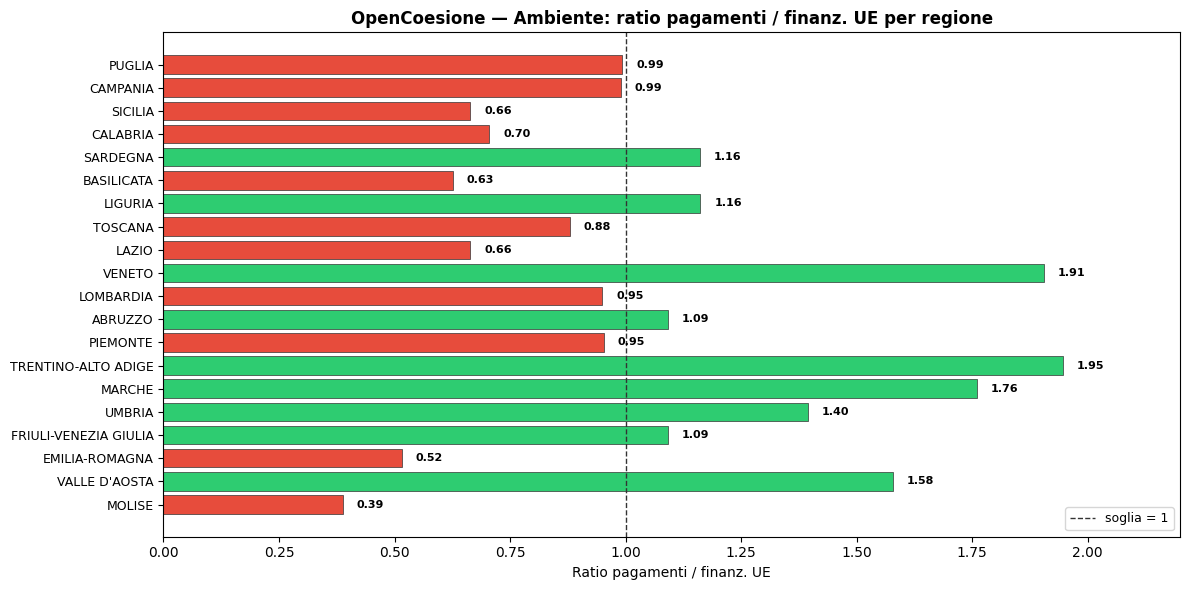

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c' if r < 1 else '#2ecc71' for r in df['ratio_spesa']]
bars = ax.barh(range(len(df)), df['ratio_spesa'], color=colors, edgecolor='#333', linewidth=0.5)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['regione'], fontsize=9)
ax.set_xlim(0, 2.2)
ax.axvline(x=1, color='#333', linestyle='--', linewidth=1, label='soglia = 1')
ax.set_xlabel('Ratio pagamenti / finanz. UE', fontsize=10)
ax.set_title('OpenCoesione — Ambiente: ratio pagamenti / finanz. UE per regione', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()

# Annotazioni
for i, (r, row) in enumerate(zip(df['ratio_spesa'], df.itertuples())):
    label = f"{r:.2f}"
    ax.text(r + 0.03, i, label, va='center', fontsize=8, fontweight='bold')

plt.tight_layout()

figures_dir = Path.cwd() / '..' / '..' / 'preview'
figures_dir.mkdir(parents=True, exist_ok=True)
out = figures_dir / 'opencoesione_ambiente_regioni_ratio.png'
plt.savefig(out, dpi=150)
plt.show()


### 3. Quanto pesano le grandi regioni del Sud?

Puglia + Campania da sole rappresentano il **58.3%** del finanziamento UE Ambiente totale.
Verifichiamo la quota.

In [5]:
nazionale = con.execute(
    """
    SELECT
        round(sum(finanz_ue_tot), 0) AS tot_ue,
        round(sum(tot_pagamenti_tot), 0) AS tot_pag,
        round(sum(tot_pagamenti_tot) / sum(finanz_ue_tot), 3) AS ratio
    FROM read_parquet($path)
    WHERE tema = 'Ambiente'
    """,
    {'path': str(mart_path)},
).fetchdf()

top2 = df[df['regione'].isin(['PUGLIA', 'CAMPANIA'])]
top2_quota = round(top2['finanz_ue_tot'].sum() / nazionale['tot_ue'].iloc[0] * 100, 1)

print(f"Totale UE Ambiente: {nazionale['tot_ue'].iloc[0]:,.0f}")
print(f"Ratio nazionale: {nazionale['ratio'].iloc[0]:.3f}")
print(f"Puglia + Campania = {top2_quota}% del finanziamento UE Ambiente")
print(f"Loro ratio medio: {top2['ratio_spesa'].mean():.3f}")


Totale UE Ambiente: 3,726,336,667
Ratio nazionale: 0.921
Puglia + Campania = 58.3% del finanziamento UE Ambiente
Loro ratio medio: 0.992


### 4. Conclusioni

La domanda guida era: **il pattern Ambiente sotto quota 1 e' diffuso o concentrato?**

La risposta e': **concentrato**.

- Puglia e Campania (58.3% del totale UE Ambiente) trainano il dato nazionale verso il basso, ma sono quasi al pareggio (0.99)
- Sicilia (0.66), Calabria (0.70), Lazio (0.66), Basilicata (0.63), Emilia-Romagna (0.52), Molise (0.39): il ritardo e' reale e piu' forte della media
- Ma 10 regioni su 20 sono sopra 1, alcune di molto: Veneto 1.91, Trentino 1.95, Marche 1.76, Valle d'Aosta 1.58

**Caveat**: il ratio > 1 non significa necessariamente "piu' efficiente". Puo' riflettere rendicontazioni diverse, co-finanziamenti nazionali anticipati, o effetti contabili tra cicli di programmazione. Serve una nota metodologica prima di trarre conclusioni forti.

**Prossimo passo naturale**: filtrare per ciclo di programmazione (2014-2020 vs 2007-2013) e capire se il pattern cambia.